<a href="https://www.kaggle.com/code/haymig/catboost-model?scriptVersionId=322473988" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

#  Bank Account Ownership Prediction
### Zindi Financial Inclusion Challenge — CatBoost + Cross-Validation Pipeline

---

> **Goal:** Predict whether an individual in East Africa owns a bank account, using demographic and socioeconomic features.  
> **Model:** CatBoostClassifier with 10-Fold Stratified Cross-Validation  
> **Metric:** Mean Absolute Error (MAE)

---

##  Step 1 — Imports

We import the core libraries needed for the pipeline:

| Library | Purpose |
|---|---|
| `pandas` | Data loading, manipulation, and feature engineering |
| `numpy` | Numerical operations and array aggregation |
| `catboost` | Gradient boosting model with native categorical support |
| `sklearn` | Stratified K-Fold splitting and evaluation metrics |
| `matplotlib` / `seaborn` | Visualizations throughout the notebook |

> **Why CatBoost?** Unlike XGBoost or LightGBM, CatBoost handles categorical features *natively* without requiring manual label encoding, reducing preprocessing overhead and often improving accuracy on mixed-type tabular data.

In [1]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Global plot style ──────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
PALETTE = ['#2ECC71', '#E74C3C', '#3498DB', '#F39C12', '#9B59B6']

print('All libraries imported successfully.')

All libraries imported successfully.


---
##  Step 2 — Load Data

We load the train and test CSVs provided by the competition. After loading, we inspect basic shape and a quick preview of the training data.

> **Why preview immediately?** Early sanity checks catch common issues: unexpected column names, encoding artifacts, or extra whitespace that would silently break downstream operations.

In [2]:
train_df = pd.read_csv('/kaggle/input/datasets/haymig/zindi-dataset/Train.csv')
test_df  = pd.read_csv('/kaggle/input/datasets/haymig/zindi-dataset/Test.csv')

print(f'Train shape : {train_df.shape}')
print(f'Test shape  : {test_df.shape}')
print(f'\nColumns: {list(train_df.columns)}')
train_df.head(3)

Train shape : (23524, 13)
Test shape  : (10086, 12)

Columns: ['country', 'year', 'uniqueid', 'bank_account', 'location_type', 'cellphone_access', 'household_size', 'age_of_respondent', 'gender_of_respondent', 'relationship_with_head', 'marital_status', 'education_level', 'job_type']


,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed


=== Missing values (train) ===
Series([], )

=== Target distribution (raw) ===
bank_account
No     20212
Yes     3312
Name: count, dtype: int64


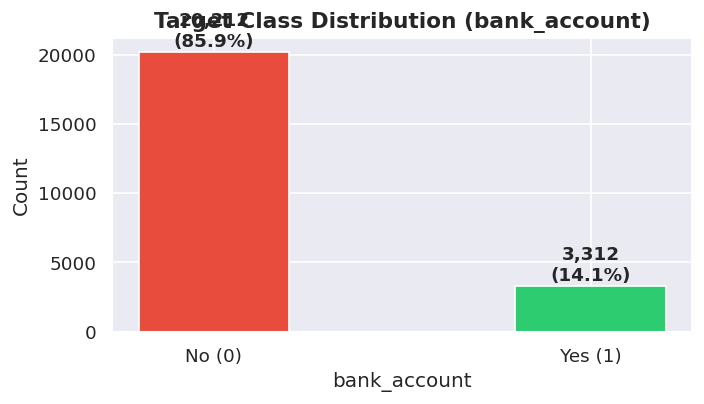

 Class imbalance detected — Stratified K-Fold will preserve this ratio in every fold.


In [3]:
# ── Quick data-quality audit ───────────────────────────────────────
print('=== Missing values (train) ===')
print(train_df.isnull().sum()[train_df.isnull().sum() > 0].to_string() or 'None — data is complete ')

print('\n=== Target distribution (raw) ===')
print(train_df['bank_account'].value_counts())

# ── Visualise target class balance ────────────────────────────────
counts = train_df['bank_account'].value_counts()
fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(counts.index, counts.values, color=['#E74C3C', '#2ECC71'], width=0.4, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{val:,}\n({val/counts.sum()*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Target Class Distribution (bank_account)', fontsize=13, fontweight='bold')
ax.set_xlabel('bank_account')
ax.set_ylabel('Count')
ax.set_xticks([0, 1])
ax.set_xticklabels(['No (0)', 'Yes (1)'])
plt.tight_layout()
plt.show()
print(' Class imbalance detected — Stratified K-Fold will preserve this ratio in every fold.')

---
##  Step 3 — Target & Binary Encoding

### 3a — Target Encoding
The target column `bank_account` stores `'Yes'` / `'No'` strings. We convert these to **binary integers** (1/0) so the model can compute loss functions numerically.

### 3b — Binary Feature Encoding
Two columns (`cellphone_access`, `gender_of_respondent`) have exactly two possible string values. We map them to 0/1 using a single shared dictionary:

```
Yes   → 1   |   No     → 0
Male  → 1   |   Female → 0
```

> **Why not one-hot?** For strictly binary features, a single integer column carries the same information as two one-hot columns — with half the memory and no multicollinearity risk.

Encoding done. Sample values:
   bank_account  cellphone_access  gender_of_respondent
0             1                 1                     0
1             0                 0                     0
2             1                 1                     1
3             0                 1                     0


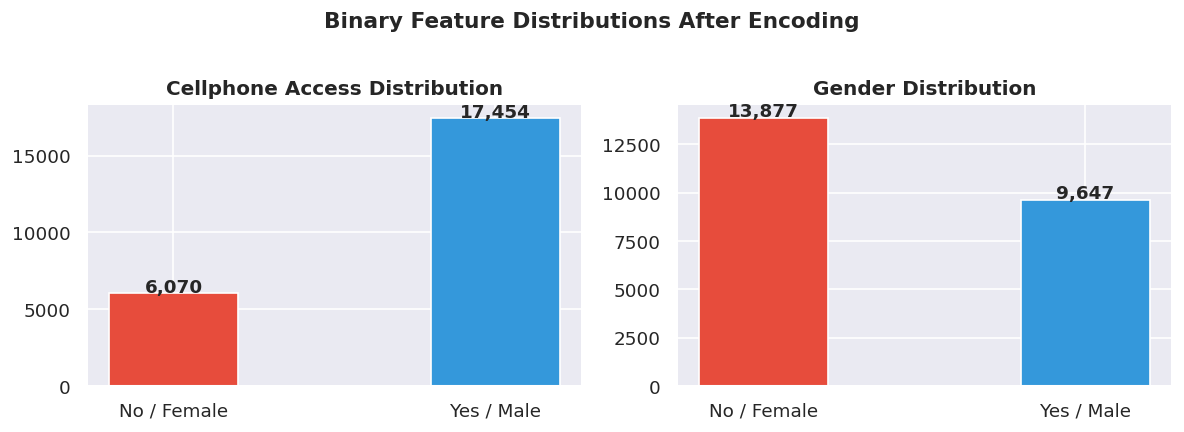

In [4]:
# ── 3a: Target encoding ────────────────────────────────────────────
train_df['bank_account'] = train_df['bank_account'].replace({'Yes': 1, 'No': 0})

# ── 3b: Binary column encoding ────────────────────────────────────
bin_cols = ['cellphone_access', 'gender_of_respondent']
mapping  = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}

for col in bin_cols:
    train_df[col] = train_df[col].map(mapping)
    test_df[col]  = test_df[col].map(mapping)

print('Encoding done. Sample values:')
print(train_df[['bank_account', 'cellphone_access', 'gender_of_respondent']].head(4))

# ── Visualise binary feature distributions ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, col, label in zip(axes, bin_cols, ['Cellphone Access', 'Gender']):
    vc = train_df[col].value_counts().sort_index()
    ax.bar([0, 1], vc.values, color=['#E74C3C', '#3498DB'], width=0.4, edgecolor='white')
    ax.set_title(f'{label} Distribution', fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No / Female', 'Yes / Male'])
    for i, v in enumerate(vc.values):
        ax.text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')
plt.suptitle('Binary Feature Distributions After Encoding', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
##  Step 4 — Feature Engineering

We create two new features to give the model richer signals:

| New Feature | Formula | Rationale |
|---|---|---|
| `edu_job_combo` | `education_level + "_" + job_type` | Captures interaction between education and employment — e.g. a *university-educated self-employed* person likely behaves differently from a *primary-educated self-employed* person |
| `household_pressure` | `household_size / (age + 1)` | Proxy for financial burden relative to life stage. A young person supporting a large household faces more pressure than an older person in the same household |

> **Why interaction features?** Tree-based models *can* learn interactions, but explicit combinations provide a direct shortcut — especially useful when the two base features appear far apart in the feature matrix.

New feature — edu_job_combo unique combos : 58
New feature — household_pressure range   : 0.010 – 0.833


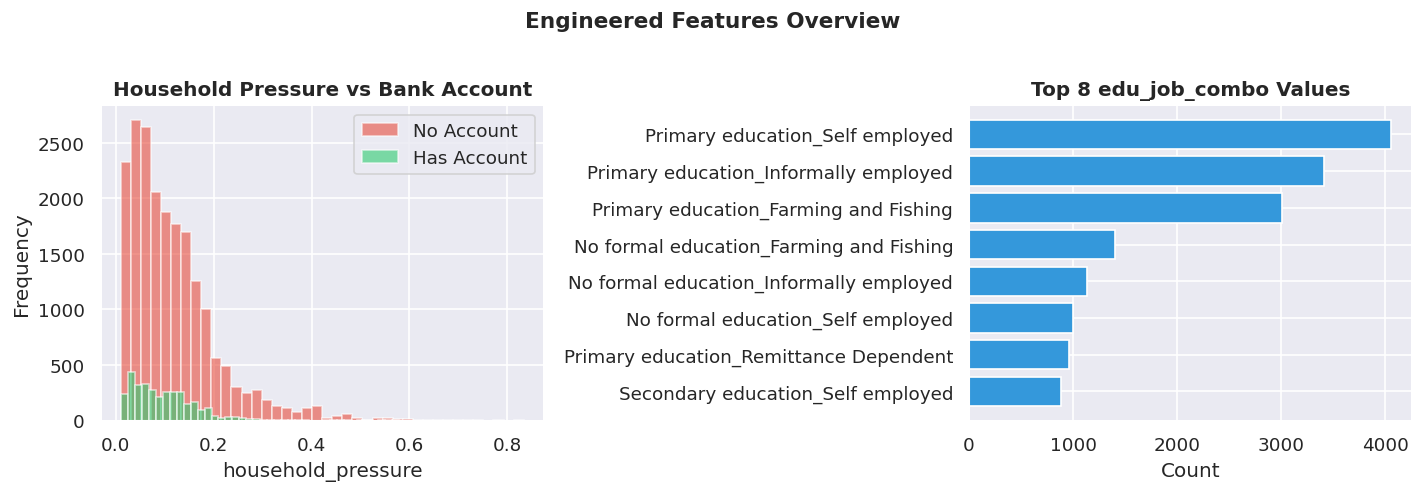

In [5]:
def create_features(data):
    # Categorical interaction: education × job type
    data['edu_job_combo'] = (data['education_level'].astype(str) + '_' +
                             data['job_type'].astype(str))
    # Continuous interaction: household burden relative to age
    data['household_pressure'] = data['household_size'] / (data['age_of_respondent'] + 1)
    return data

train_df = create_features(train_df)
test_df  = create_features(test_df)

print(f'New feature — edu_job_combo unique combos : {train_df["edu_job_combo"].nunique()}')
print(f'New feature — household_pressure range   : {train_df["household_pressure"].min():.3f} – {train_df["household_pressure"].max():.3f}')

# ── Visualise household_pressure by bank account ownership ────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of household_pressure split by target
for label, color in [(0, '#E74C3C'), (1, '#2ECC71')]:
    axes[0].hist(train_df[train_df['bank_account'] == label]['household_pressure'],
                 bins=40, alpha=0.6, color=color,
                 label='No Account' if label == 0 else 'Has Account')
axes[0].set_title('Household Pressure vs Bank Account', fontweight='bold')
axes[0].set_xlabel('household_pressure')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Top edu_job_combo combos
top_combos = train_df['edu_job_combo'].value_counts().head(8)
axes[1].barh(top_combos.index[::-1], top_combos.values[::-1], color='#3498DB', edgecolor='white')
axes[1].set_title('Top 8 edu_job_combo Values', fontweight='bold')
axes[1].set_xlabel('Count')

plt.suptitle('Engineered Features Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
##  Step 5 — Country-Based Age Features

We add two geography-aware features:

| Feature | How | Why |
|---|---|---|
| `avg_age_country` | Group mean of `age_of_respondent` by `country` | Captures the demographic profile of each country's survey population |
| `age_gap` | Individual age − country average | Measures whether a respondent is *older or younger* than their countrymen — a proxy for generational positioning relative to local norms |

> **Important:** We compute `avg_age_country` **separately** for train and test using `.groupby().transform('mean')` — this avoids data leakage by never letting test statistics influence training statistics.

Country average ages:
country
Kenya       39.62
Rwanda      39.29
Tanzania    38.48
Uganda      35.46
Name: age_of_respondent, dtype: float64


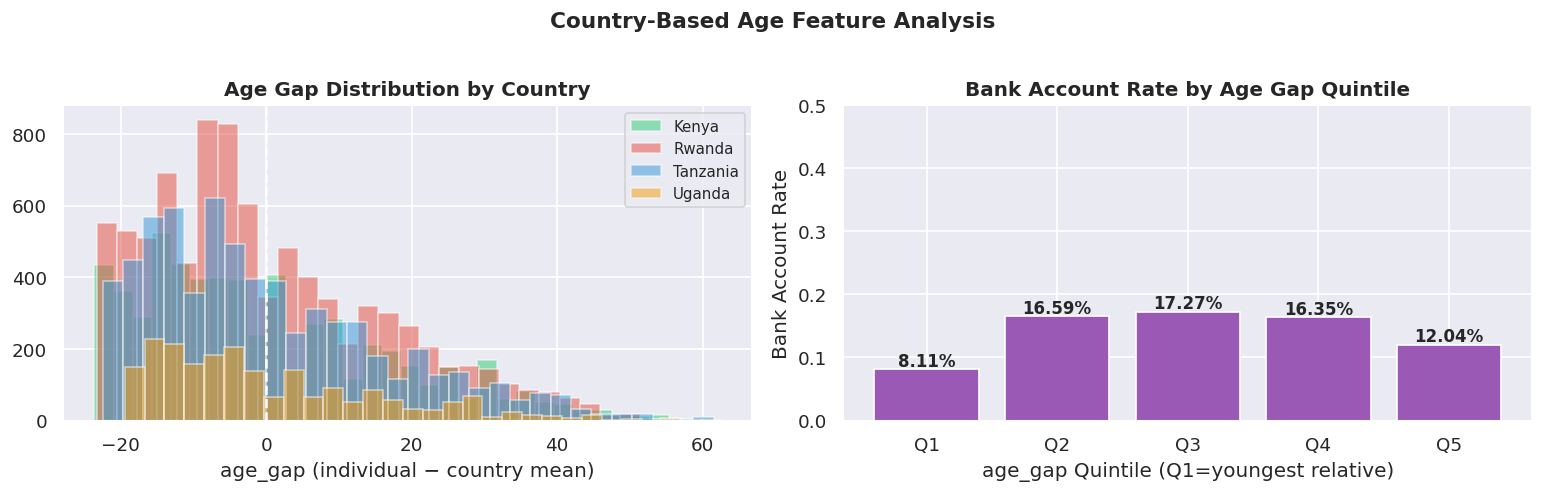

In [6]:
train_df['avg_age_country'] = train_df.groupby('country')['age_of_respondent'].transform('mean')
test_df['avg_age_country']  = test_df.groupby('country')['age_of_respondent'].transform('mean')

train_df['age_gap'] = train_df['age_of_respondent'] - train_df['avg_age_country']
test_df['age_gap']  = test_df['age_of_respondent']  - test_df['avg_age_country']

print('Country average ages:')
print(train_df.groupby('country')['age_of_respondent'].mean().round(2))

# ── Visualise age_gap distribution by country ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

countries = train_df['country'].unique()
colors_map = dict(zip(countries, PALETTE))

for country in countries:
    subset = train_df[train_df['country'] == country]['age_gap']
    axes[0].hist(subset, bins=30, alpha=0.5, label=country, color=colors_map[country])
axes[0].axvline(0, color='white', linestyle='--', linewidth=1.5)
axes[0].set_title('Age Gap Distribution by Country', fontweight='bold')
axes[0].set_xlabel('age_gap (individual − country mean)')
axes[0].legend(fontsize=9)

# Bank account rate vs age_gap quintile
train_df['age_gap_q'] = pd.qcut(train_df['age_gap'], q=5, labels=['Q1','Q2','Q3','Q4','Q5'])
rate_by_q = train_df.groupby('age_gap_q')['bank_account'].mean()
axes[1].bar(rate_by_q.index, rate_by_q.values, color='#9B59B6', edgecolor='white')
axes[1].set_title('Bank Account Rate by Age Gap Quintile', fontweight='bold')
axes[1].set_xlabel('age_gap Quintile (Q1=youngest relative)')
axes[1].set_ylabel('Bank Account Rate')
axes[1].set_ylim(0, 0.5)
for i, v in enumerate(rate_by_q.values):
    axes[1].text(i, v + 0.005, f'{v:.2%}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Country-Based Age Feature Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Clean up helper column
train_df.drop(columns=['age_gap_q'], inplace=True)

---
##  Step 6 — Prepare Final Feature Sets

We drop columns that should **not** be used as model inputs:

| Column Dropped | Reason |
|---|---|
| `bank_account` | This is the target |
| `uniqueid` | Arbitrary row identifier — no predictive signal |
| `avg_age_country` | Already encoded in `age_gap`; retaining it would duplicate information |

We also define `cat_cols` — the list of categorical column names to pass to CatBoost. CatBoost uses this list to apply its **ordered target statistics** encoding internally, which is more robust than naive label/ordinal encoding.

Feature matrix shape (train) : (23524, 14)
Feature matrix shape (test)  : (10086, 14)

Categorical features (7): ['country', 'location_type', 'relationship_with_head', 'marital_status', 'education_level', 'job_type', 'edu_job_combo']
Numeric features    (7): ['year', 'cellphone_access', 'household_size', 'age_of_respondent', 'gender_of_respondent', 'household_pressure', 'age_gap']


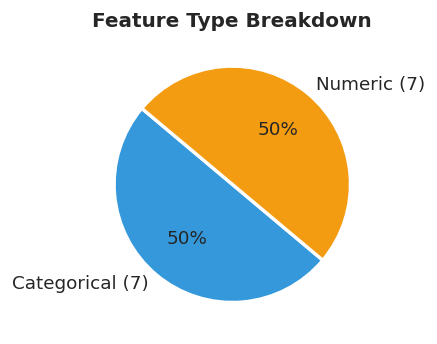

In [7]:
target       = train_df['bank_account']
features     = train_df.drop(columns=['bank_account', 'uniqueid', 'avg_age_country'])
test_features = test_df.drop(columns=['uniqueid', 'avg_age_country'])

cat_cols = [
    'country', 'location_type', 'relationship_with_head',
    'marital_status', 'education_level', 'job_type', 'edu_job_combo'
]

print(f'Feature matrix shape (train) : {features.shape}')
print(f'Feature matrix shape (test)  : {test_features.shape}')
print(f'\nCategorical features ({len(cat_cols)}): {cat_cols}')
print(f'Numeric features    ({len(features.columns) - len(cat_cols)}):',
      [c for c in features.columns if c not in cat_cols])

# ── Feature type breakdown ─────────────────────────────────────────
n_cat = len(cat_cols)
n_num = len(features.columns) - n_cat
fig, ax = plt.subplots(figsize=(5, 3))
ax.pie([n_cat, n_num], labels=[f'Categorical ({n_cat})', f'Numeric ({n_num})'],
       colors=['#3498DB', '#F39C12'], autopct='%1.0f%%',
       startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Feature Type Breakdown', fontweight='bold')
plt.tight_layout()
plt.show()

---
##  Step 7 — 10-Fold Stratified Cross-Validation with CatBoost

### Why Stratified K-Fold?
Because the dataset is **class-imbalanced** (~80% No / ~20% Yes), random splits could produce folds with very different positive-class proportions. `StratifiedKFold` ensures each fold mirrors the overall ratio — giving more reliable MAE estimates.

### CatBoost Hyperparameters Explained

| Parameter | Value | Rationale |
|---|---|---|
| `iterations` | 2000 | Upper bound on tree count; early stopping will typically halt before this |
| `learning_rate` | 0.02 | Low rate → slower but more generalizable convergence |
| `depth` | 7 | Moderate depth captures feature interactions without overfitting |
| `l2_leaf_reg` | 12 | Strong L2 regularisation to penalise complex leaves |
| `bootstrap_type` | `'Bayesian'` | Bayesian row sampling is the most noise-robust option for CatBoost |
| `early_stopping_rounds` | 100 | Stops if validation MAE doesn't improve for 100 consecutive trees |

### Prediction Strategy
- **Validation:** Hard label prediction (`predict`) for computing fold MAE  
- **Test:** Soft probability prediction (`predict_proba[:, 1]`) — we average probabilities across folds before thresholding, which is more stable than voting on hard labels.

In [8]:
kf         = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
test_preds = []
scores     = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(features, target)):

    X_train, X_valid = features.iloc[tr_idx], features.iloc[val_idx]
    y_train, y_valid = target.iloc[tr_idx],   target.iloc[val_idx]

    clf = CatBoostClassifier(
        iterations       = 2000,
        learning_rate    = 0.02,
        depth            = 7,
        l2_leaf_reg      = 12,
        bootstrap_type   = 'Bayesian',
        random_seed      = 42,
        verbose          = 0
    )

    clf.fit(
        X_train, y_train,
        cat_features         = cat_cols,
        eval_set             = (X_valid, y_valid),
        early_stopping_rounds = 100
    )

    val_pred   = clf.predict(X_valid)
    fold_score = mean_absolute_error(y_valid, val_pred)
    scores.append(fold_score)

    test_preds.append(clf.predict_proba(test_features)[:, 1])
    print(f'  Fold {fold+1:02d} | Best iteration: {clf.best_iteration_:>4d} | MAE: {fold_score:.5f}')

print(f'\nCV MAE (10-Fold): {np.mean(scores):.5f}  ±  {np.std(scores):.5f}')

  Fold 01 | Best iteration:  583 | MAE: 0.11092
  Fold 02 | Best iteration:  597 | MAE: 0.11475
  Fold 03 | Best iteration:  430 | MAE: 0.11220
  Fold 04 | Best iteration:  313 | MAE: 0.10625
  Fold 05 | Best iteration:  466 | MAE: 0.11224
  Fold 06 | Best iteration:  736 | MAE: 0.10119
  Fold 07 | Best iteration: 1321 | MAE: 0.11692
  Fold 08 | Best iteration:  918 | MAE: 0.11224
  Fold 09 | Best iteration:  668 | MAE: 0.11352
  Fold 10 | Best iteration:  679 | MAE: 0.10757

CV MAE (10-Fold): 0.11078  ±  0.00436


---
##  Step 8 — Cross-Validation Results Visualisation

Plotting per-fold MAE helps us:
- Spot any **outlier folds** that may indicate a particularly hard or easy data split
- Assess **model stability** — a tight variance across folds is a good sign
- Report results with proper uncertainty bounds (mean ± std)

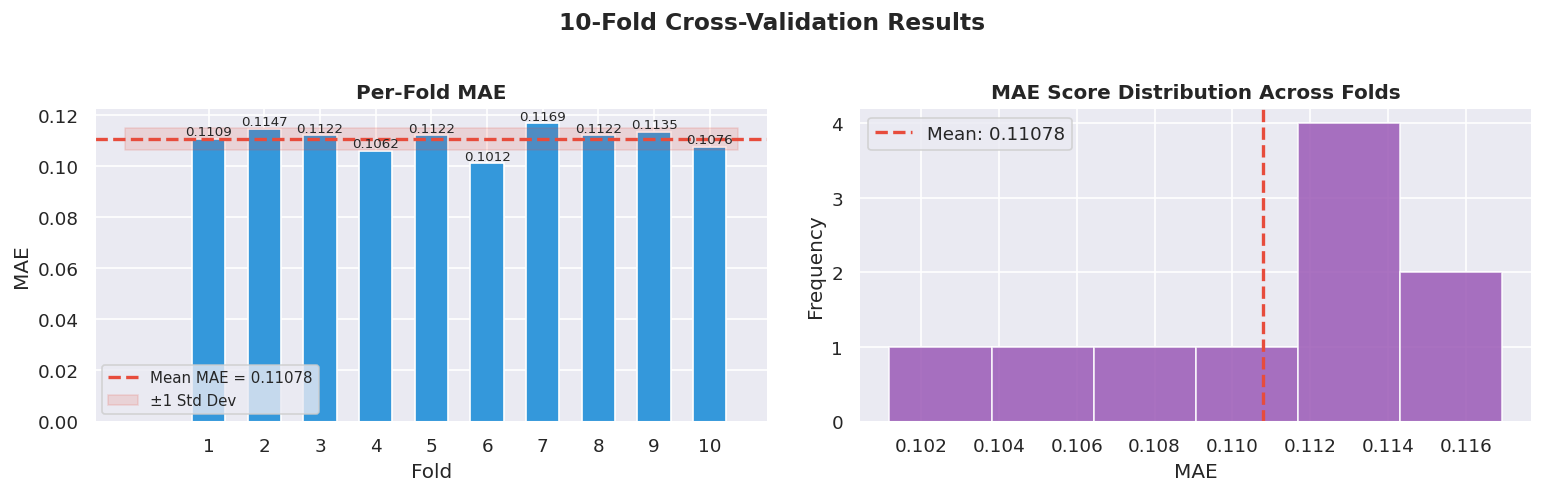

Best fold  : Fold 6 — MAE 0.10119
Worst fold : Fold 7 — MAE 0.11692
Spread     : 0.01573


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

fold_nums = list(range(1, 11))

# Per-fold MAE bar chart
bars = axes[0].bar(fold_nums, scores, color='#3498DB', edgecolor='white', width=0.6)
axes[0].axhline(np.mean(scores), color='#E74C3C', linestyle='--', linewidth=2,
                label=f'Mean MAE = {np.mean(scores):.5f}')
axes[0].fill_between([-0.5, 10.5],
                     np.mean(scores) - np.std(scores),
                     np.mean(scores) + np.std(scores),
                     alpha=0.15, color='#E74C3C', label='±1 Std Dev')
for bar, s in zip(bars, scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
                 f'{s:.4f}', ha='center', va='bottom', fontsize=8)
axes[0].set_title('Per-Fold MAE', fontweight='bold')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('MAE')
axes[0].set_xticks(fold_nums)
axes[0].legend(fontsize=9)

# Distribution of MAE scores
axes[1].hist(scores, bins=6, color='#9B59B6', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(scores), color='#E74C3C', linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(scores):.5f}')
axes[1].set_title('MAE Score Distribution Across Folds', fontweight='bold')
axes[1].set_xlabel('MAE')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('10-Fold Cross-Validation Results', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Best fold  : Fold {np.argmin(scores)+1} — MAE {min(scores):.5f}')
print(f'Worst fold : Fold {np.argmax(scores)+1} — MAE {max(scores):.5f}')
print(f'Spread     : {max(scores) - min(scores):.5f}')

---
##  Step 9 — Feature Importance

CatBoost computes feature importance as the **average gain** contributed by each feature across all trees and all folds. We retrieve importance from the last trained fold for a representative view.

> **Why inspect importance?** It validates that the model is learning from sensible signals. If a noisy or leaky feature ranks top, that's a red flag. It also guides future feature engineering — features near the bottom may be dropped to reduce overfitting.

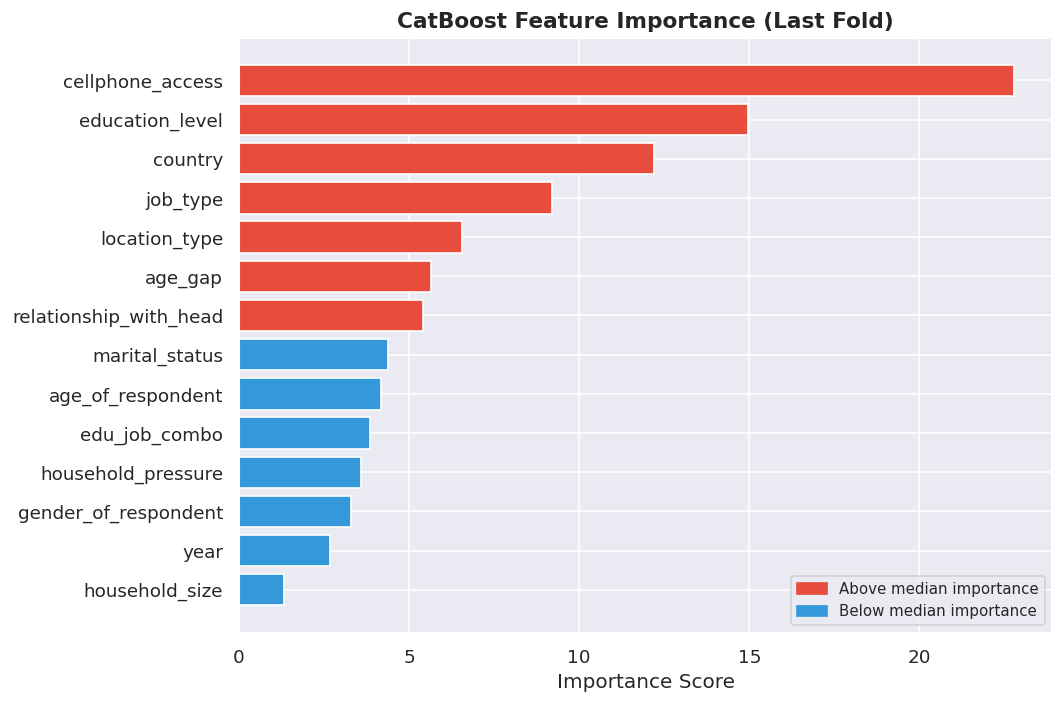

Top 5 most important features:
         feature  importance
cellphone_access   22.773276
 education_level   14.973602
         country   12.184687
        job_type    9.206125
   location_type    6.565667


In [10]:
# Use the last fold's model for feature importance
importance_df = pd.DataFrame({
    'feature'   : features.columns,
    'importance': clf.get_feature_importance()
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#E74C3C' if imp > importance_df['importance'].median() else '#3498DB'
          for imp in importance_df['importance']]
ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1],
        color=colors[::-1], edgecolor='white')
ax.set_title('CatBoost Feature Importance (Last Fold)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
above_patch = mpatches.Patch(color='#E74C3C', label='Above median importance')
below_patch = mpatches.Patch(color='#3498DB', label='Below median importance')
ax.legend(handles=[above_patch, below_patch], fontsize=9)
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(importance_df.head(5).to_string(index=False))

---
##  Step 10 — Aggregate Test Predictions & Threshold

### Why average probabilities?
Each of the 10 folds produces a probability score for every test row. Averaging these 10 probability vectors before applying a threshold is more robust than:
- Hard majority-vote (loses calibration information)
- Using only one fold (high variance)

### Threshold = 0.5
We use the standard 0.5 decision boundary. If the competition metric rewards a different precision/recall trade-off, this threshold can be tuned using the validation sets.

> `final_prob > 0.5 → 1 (Has Bank Account)`  
> `final_prob ≤ 0.5 → 0 (No Bank Account)`

Test predictions — class 1 rate : 7.158%
Probability range               : [0.0023, 0.9599]


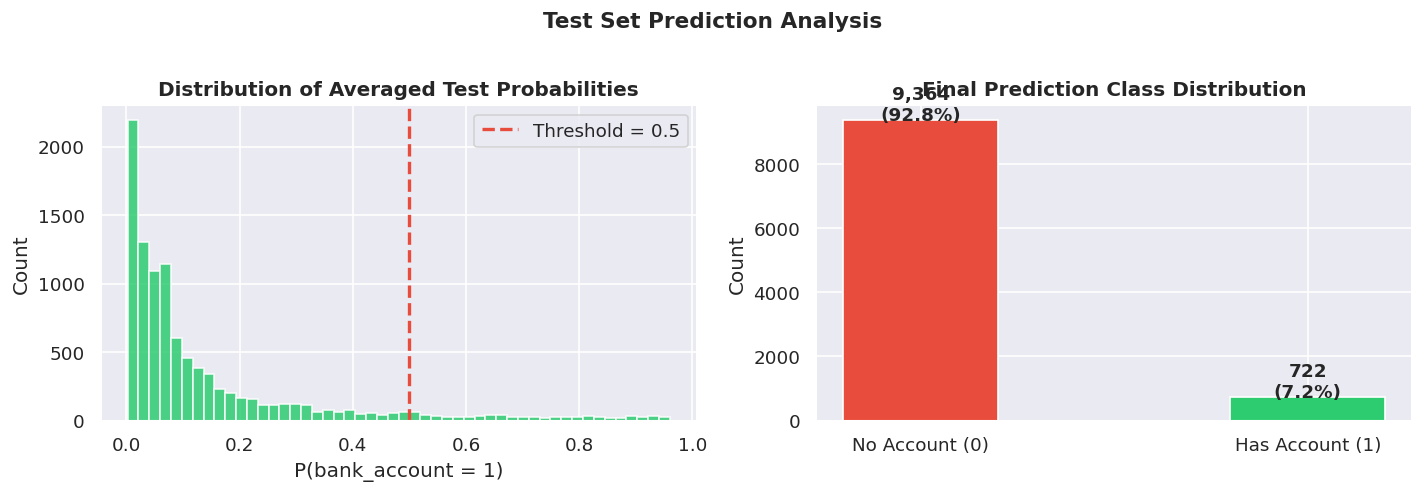

In [11]:
final_prob   = np.mean(test_preds, axis=0)        # Average over 10 folds
final_output = (final_prob > 0.5).astype(int)     # Hard threshold

print(f'Test predictions — class 1 rate : {final_output.mean():.3%}')
print(f'Probability range               : [{final_prob.min():.4f}, {final_prob.max():.4f}]')

# ── Visualise probability distribution ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(final_prob, bins=50, color='#2ECC71', edgecolor='white', alpha=0.85)
axes[0].axvline(0.5, color='#E74C3C', linestyle='--', linewidth=2, label='Threshold = 0.5')
axes[0].set_title('Distribution of Averaged Test Probabilities', fontweight='bold')
axes[0].set_xlabel('P(bank_account = 1)')
axes[0].set_ylabel('Count')
axes[0].legend()

counts_out = pd.Series(final_output).value_counts().sort_index()
axes[1].bar(['No Account (0)', 'Has Account (1)'], counts_out.values,
            color=['#E74C3C', '#2ECC71'], edgecolor='white', width=0.4)
for i, v in enumerate(counts_out.values):
    axes[1].text(i, v + 20, f'{v:,}\n({v/len(final_output):.1%})',
                 ha='center', fontweight='bold')
axes[1].set_title('Final Prediction Class Distribution', fontweight='bold')
axes[1].set_ylabel('Count')

plt.suptitle('Test Set Prediction Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
##  Step 11 — Build & Save Submission

The competition requires a specific ID format: `uniqueid + ' x ' + country`. We construct this, attach our predictions, and save to `submission_6.csv`.

> **Final check:** We verify the submission shape and preview the first few rows before saving to ensure no formatting issues sneak in.

In [12]:
submission = pd.DataFrame({
    'unique_id'    : test_df['uniqueid'] + ' x ' + test_df['country'],
    'bank_account' : final_output
})

# Final sanity checks
assert submission.isnull().sum().sum() == 0, 'Nulls found in submission!'
assert set(submission['bank_account'].unique()).issubset({0, 1}), ' Non-binary predictions!'
assert len(submission) == len(test_df), ' Row count mismatch!'

submission.to_csv('submission_7.csv', index=False)

print(' All checks passed. Submission saved.')
print(f'\nSubmission shape : {submission.shape}')
print(f'Class distribution:\n{submission["bank_account"].value_counts()}')
print(f'\nPreview:')
submission.head(5)

 All checks passed. Submission saved.

Submission shape : (10086, 2)
Class distribution:
bank_account
0    9364
1     722
Name: count, dtype: int64

Preview:


,unique_id,bank_account
0,uniqueid_6056 x Kenya,1
1,uniqueid_6060 x Kenya,1
2,uniqueid_6065 x Kenya,0
3,uniqueid_6072 x Kenya,0
4,uniqueid_6073 x Kenya,0


---

## Summary

| Stage | Action | Key Decision |
|---|---|---|
| Data Loading | Read Train/Test CSVs | Immediate shape & null check |
| Encoding | Target + binary columns → 0/1 | Avoids label encoding overhead for 2-value columns |
| Feature Engineering | `edu_job_combo`, `household_pressure` | Explicit interaction features help tree models |
| Geo Features | `avg_age_country`, `age_gap` | Country-relative positioning without data leakage |
| Modelling | CatBoostClassifier | Native categorical support, strong regularisation |
| Validation | 10-Fold StratifiedKFold | Reliable MAE estimate on imbalanced classes |
| Aggregation | Average probabilities over folds | Reduces variance vs single-fold or hard voting |
| Submission | uniqueid + country key | Competition-required format |

---
